In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Install Essential Libraries:

In [2]:
!pip install datasets transformers

In [3]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from datasets import Dataset
import re

## Test Cleaning Text Function:

In [4]:
text1 = '❤️ !أهٌلا 87 بكم'

**clean arabic text:**

In [4]:
def clean_arabic(text):
  # remove any character nither string nor digit:
  t1 = re.sub(r'[^0-9\u0600-\u06FF\s]', '', text)
  # remove tashkeel symbols:
  t2 = re.sub(r'[\u064B-\u0652\u0653-\u0655\u0670]', '', t1).strip()

  return t2


In [17]:
# test function:
print(clean_arabic(text1))

NameError: name 'text1' is not defined

**clean english text:**

In [7]:
text2 = "Welcome 55,,, dears!"

In [5]:
def clean_english(text):
  # remove nither string nor digit:
  t1 = re.sub(r'[^a-zA-Z0-9\s]', '', text).strip()
  return t1

In [9]:
# test function:

print(clean_english(text2))

Welcome 55 dears


## The Base Datasets:

- Load datasets.
- Clean data.
- Rename columns.
- Concat DFs.

In [6]:
df1_ar = pd.read_csv('/content/drive/MyDrive/Arabic_resturant_reviews.csv')
df2_ar = pd.read_excel('/content/drive/MyDrive/Jeddah_Restaurants_Reviews_Labeled.xlsx')
df3_en = pd.read_csv('/content/drive/MyDrive/labeled_reviews_english.csv')

In [17]:
# display the df1:

df1_ar.head()

,review,label
0,المطعم يجنن والاكل تحفة,1
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,1
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,0
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,0
4,الطعام في هذا المطعم كان سيئًا للغاية والخدمة ...,0


In [32]:
# shape of df1:
df1_ar.shape

(800, 2)

In [38]:
# check the type of labels/results:
df1_ar['label'].value_counts()

,count
label,
1,400
0,400


In [7]:
# add mid motion reviews to df1 (don't intrested on other data):

mid_reviews_data = [
    {"review": "المكان جميل وهادئ، لكن الأسعار مبالغ فيها مقارنة بجودة الطعام.", "label": "mid"},
    {"review": "الأكل عادي جداً ولا يستحق الضجة، لكن طاقم العمل كان ودوداً.", "label": "mid"},
    {"review": "تجربة متوسطة، بعض الأطباق كانت لذيذة والبعض الآخر وصل بارداً.", "label": "mid"},
    {"review": "المطعم نظيف والخدمة سريعة، لكن الطعم لم يكن بالمستوى المطلوب.", "label": "mid"},
    {"review": "لا بأس به، ينفع لوجبة سريعة إذا كنت في الجوار ولكن لا أقصده خصيصاً.", "label": "mid"},
    {"review": "ديكور المطعم رائع ويفتح النفس، غير أن قائمة الطعام محدودة والخيارات قليلة.", "label": "mid"},
    {"review": "الخدمة ممتازة وسريعة، إلا أن كمية الطعام في الأطباق قليلة جداً.", "label": "mid"},
    {"review": "مستوى الطعام متذبذب؛ أحياناً يكون ممتازاً وأحياناً أخرى أقل من العادي.", "label": "mid"},
    {"review": "مطعم جيد ومناسب للعائلات، لكن المشكلة في صعوبة إيجاد موقف للسيارة.", "label": "mid"},
    {"review": "الشاورما كانت جيدة، لكن الفطائر كانت جافة بعض الشيء. تقييمي له نص نص.", "label": "mid"},
    {"review": "يمشي الحال لو كنت جائعاً جداً، لكنه بالتأكيد ليس أفضل مطعم في المدينة.", "label": "mid"},
    {"review": "التجربة بشكل عام مقبولة، لا يوجد شيء مميز يجعلك تعود مرة أخرى.", "label": "mid"},
    {"review": "اللحوم كانت مطهية بشكل جيد، لكن التوابل كانت ناقصة وتحتاج تعديل.", "label": "mid"},
    {"review": "الموظفون متعاونون، لكن المكان مزدحم جداً ومزعج مما أفسد التجربة.", "label": "mid"},
    {"review": "جودة الأكل متوسطة، السعر رخيص ومناسب للطلاب، لكن النظافة تحتاج اهتمام.", "label": "mid"}
]

df_mid = pd.DataFrame(mid_reviews_data)
df1_ar = pd.concat([df1_ar, df_mid])

In [40]:
# display the new content in df1:

df1_ar.tail()

,review,label
10,يمشي الحال لو كنت جائعاً جداً، لكنه بالتأكيد ل...,mid
11,التجربة بشكل عام مقبولة، لا يوجد شيء مميز يجعل...,mid
12,اللحوم كانت مطهية بشكل جيد، لكن التوابل كانت ن...,mid
13,الموظفون متعاونون، لكن المكان مزدحم جداً ومزعج...,mid
14,جودة الأكل متوسطة، السعر رخيص ومناسب للطلاب، ل...,mid


In [47]:
# check the type of labels/results:
df1_ar['label'].value_counts()

,count
label,
1,400
0,400
mid,15


In [42]:
# new shape of df1:

df1_ar.shape

(815, 2)

In [43]:
# display the df2:

df2_ar.head()

,ID,Review,Review Language,Restaurant Name,Restaurant Rate,Latitude,Longitude,District,Publication Date,Sentiment
0,RV001,رائع والطعم خرافي ولذيذ,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,pos
1,RV002,هذا الفرع من أسوأ فروع البيك .. يوصلك الأكل با...,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,neg
2,RV003,البيك لا نختلف عليه من طعم ولكن تقييمي للموظفي...,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,mid
3,RV004,Albaik was better than this but insha'Allah it...,English,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,mid
4,RV005,البيك الكل يعرفة ممتاز,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,pos


In [44]:
df2_ar.shape

(1536, 10)

In [45]:
# display the df3:
df3_en.head()

,Unnamed: 0,Reviews,sentiment,hugging_face_label,semantic_label
0,0,Disappointed. Surprisingly disappointed. I hav...,0.0,0,neg
1,1,Food good but waiter should advise patrons on ...,0.0,0,pos
2,2,Recently visited Ballygunge Place restaurant f...,1.0,1,pos
3,3,I was very disapoint that they do not serve ge...,0.0,0,mid
4,4,We visited 6 Ballygunge for a meal this Novemb...,1.0,1,pos


In [48]:
# check the type of labels/results:
df3_en['semantic_label'].value_counts()

,count
semantic_label,
pos,581
mid,60
neg,38


In [46]:
# shape of df3:

df3_en.shape

(679, 5)

In [8]:
# rename all columns to be the same in all DFs:
## At df1: review, label

df2_ar = df2_ar.rename(columns={'Review' : 'review', 'Sentiment' : 'label'})
df3_en = df3_en.rename(columns={'Reviews' : 'review', 'semantic_label' : 'label'})

In [20]:
df2_ar.head()

,ID,review,Review Language,Restaurant Name,Restaurant Rate,Latitude,Longitude,District,Publication Date,label
0,RV001,رائع والطعم خرافي ولذيذ,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,pos
1,RV002,هذا الفرع من أسوأ فروع البيك .. يوصلك الأكل با...,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,neg
2,RV003,البيك لا نختلف عليه من طعم ولكن تقييمي للموظفي...,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,mid
3,RV004,Albaik was better than this but insha'Allah it...,English,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,mid
4,RV005,البيك الكل يعرفة ممتاز,Arabic,Al-Baik,4.1,21.628703,39.135404,Al-Naem,2026-02-01,pos


In [9]:
# Apply cleaning the text:

df1_ar['review'] = df1_ar['review'].apply(clean_arabic)
df2_ar['review'] = df2_ar['review'].apply(clean_arabic)
df3_en['review'] = df3_en['review'].apply(clean_english)

print('Done cleaning texts')

Done cleaning texts


In [10]:
# extract only english reviews from df2, and let only arabic reviews into it:
# let only wanted columns in all DFs:

df4_en = df2_ar.loc[df2_ar['Review Language'] == 'English', ['review', 'label']]
df2_ar = df2_ar.loc[df2_ar['Review Language'] == 'Arabic', ['review', 'label']]
df3_en = df3_en[['review', 'label']]


# concrate DFs:
df_ar = pd.concat([df1_ar, df2_ar])
df_en = pd.concat([df3_en, df4_en])

In [11]:
df_ar.shape

(2135, 2)

In [12]:
df_en.shape

(888, 2)

In [13]:
df_ar['label'].value_counts()

,count
label,
pos,668
neg,482
1,400
0,400
mid,185


In [15]:
df_en['label'].value_counts()

,count
label,
pos,729
neg,80
mid,79


In [11]:
# map labels
 ## (0 : pos, 2 : mid, 1 : neg) - to be suitable for Arabic model:
 ## (2 : pos, 1 : mid, 0 : neg) - to be suitable for English model:

df_ar['label'] = df_ar['label'].map({1 : 0, 0 : 1, 'mid' : 2, 'pos' : 0, 'neg' : 1})
df_en['label'] = df_en['label'].map({'pos' : 2, 'mid' : 1, 'neg' : 0})

In [17]:
df_ar.head()

,review,label
0,المطعم يجنن والاكل تحفة,0
1,أنصح بزيارة المطعم ده بجد، الأكل عندهم لذيذ وا...,0
2,لقد كانت تجربة سيئة، الطعام غير مقبول والخدمة ...,1
3,الطاقم غير احترافي على الإطلاق، والخدمة بطيئة ...,1
4,الطعام في هذا المطعم كان سيئا للغاية والخدمة ك...,1


In [18]:
df_en.head()

,review,label
0,Disappointed Surprisingly disappointed I have ...,0
1,Food good but waiter should advise patrons on ...,2
2,Recently visited Ballygunge Place restaurant f...,2
3,I was very disapoint that they do not serve ge...,1
4,We visited 6 Ballygunge for a meal this Novemb...,2


## Semantic Models:

- Load models.
- Prepare datasets.
- Get results.
- Map labels.

In [12]:
# model names:
modelAr = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"
modelEn = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# models
pipeline_ar = pipeline("sentiment-analysis", modelAr)
pipeline_en = pipeline("sentiment-analysis", modelEn)


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

**Prepare Datasets For The Models:**

In [13]:
dataset_ar = Dataset.from_pandas(df_ar)

dataset_en = Dataset.from_pandas(df_en)

In [16]:
# get sample from datasets:

sample_ar = dataset_ar.select([10,11])
sample_en = dataset_en.select([9,10])

**Test Models:**

In [17]:
result_ar = pipeline_ar(list(sample_ar['review']))
result_en = pipeline_en(list(sample_en['review']))

In [21]:
result_ar

[{'label': 'positive', 'score': 0.9905878305435181},
 {'label': 'negative', 'score': 0.9942848086357117}]

In [18]:
# extract only text:
sample_ar[0]['review']

'المطعم ده بجد بيديك إحساس بالسعادة الكاملة، الأكل فيه بيديك شعور بالسلام الداخلي والراحة'

In [19]:
# function of print results:

def printResults(textAr, textEn, resultAr, resultEn):

  for i in range(len(resultAr)):
    print(f'Arabic Review: {textAr[i]['review']}\nResult: {resultAr[i]['label']} - PCT: {round(resultAr[i]['score'] *100, 2)}%\n\n')

    print(f'English Review: {textEn[i]['review']}\nResult: {resultEn[i]['label']} - PCT: {round(resultEn[i]['score'] *100, 2)}%\n\n')

In [36]:
printResults(resultAr=result_ar, resultEn=result_en, textAr=sample_ar, textEn=sample_en)

Arabic Review: المطعم ده بجد بيديك إحساس بالسعادة الكاملة، الأكل فيه بيديك شعور بالسلام الداخلي والراحة
Result: positive - PCT: 99.06%


English Review: If your looking for an authentic bengali cuisine then 6 ballygunge place is where you should be The food is made in authentic bengali style Wide buffet spread The taste is superb Must try is luchi and kosha mangsho along with aloo dum The aamMore
Result: positive - PCT: 95.84%


Arabic Review: المطعم هذا ما يستاهل الزيارة، الطعام مرة سيء جدا والخدمة سيئة للغاية
Result: negative - PCT: 99.43%


English Review: My wife is Bengali and I am very accustomed to her cooking Having been to many Bengali parties hosted by our friends Im familiar enough to at least have a valid opinion I ate at six different restaurants in Kolkata and this one was nearMore
Result: positive - PCT: 52.54%




**Check Label Results Are Right:**

In [52]:
pipeline_ar.model.config.id2label

{0: 'positive', 1: 'negative', 2: 'neutral'}

In [55]:
pipeline_en.model.config.id2label

{0: 'negative', 1: 'neutral', 2: 'positive'}

## Test Models With Full Datasets:

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

In [14]:
X_ar = dataset_ar['review']
y_ar = dataset_ar['label']

X_en = dataset_en['review']
y_en = dataset_en['label']

NameError: name 'dataset_ar' is not defined

In [ ]:
x_trainAr, x_testAr, y_trainAr, y_testAr = train_test_split(list(X_ar), list(y_ar), test_size=0.2, shuffle=True, random_state=42)

x_trainEn, x_testEn, y_trainEn, y_testEn = train_test_split(list(X_en), list(y_en), test_size=0.2, shuffle=True, random_state=42)

In [24]:
# test models:

results_ar = pipeline_ar(x_testAr)
reuslts_en = pipeline_en(x_testEn)

In [15]:
# extract labels:

def extractLabels(textAr, textEn):
  map_ar = {'positive' : 0, 'negative' : 1, 'neutral' : 2}
  map_en = {'positive' : 2, 'negative' : 0, 'neutral' : 1}

  labels_ar = []
  labels_en = []

  for i in range(len(textAr)):
    labels_ar.append(map_ar[textAr[i]['label']])

  for i in range(len(textEn)):
    labels_en.append(map_en[textEn[i]['label']])

  return labels_ar, labels_en

In [26]:
labels_ar, labels_en = extractLabels(textAr=results_ar, textEn=reuslts_en)

In [27]:
print(classification_report(y_pred=labels_ar, y_true=y_testAr))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       215
           1       0.87      0.87      0.87       174
           2       0.35      0.24      0.28        38

    accuracy                           0.84       427
   macro avg       0.70      0.68      0.68       427
weighted avg       0.83      0.84      0.83       427



In [28]:
print(classification_report(y_pred=labels_en, y_true=y_testEn))

              precision    recall  f1-score   support

           0       0.50      0.45      0.47        20
           1       0.50      0.26      0.34        19
           2       0.88      0.95      0.91       139

    accuracy                           0.82       178
   macro avg       0.63      0.55      0.58       178
weighted avg       0.80      0.82      0.80       178



Fof Arabic mode, we get a good results, but English model not. At Arabic model it has weakness at mid motion reviews, and for English model it has more weakness in general.
- Will Add more English dataset to make model train on more data.
- Will Add more natural Arbic reviews to make model learn on more from this type.
- Will Add more positive, negative Arbic reviews to let Arabic model learn from more patterns to be more accurate.


## Fine-Tune Models:

- Load new datasets.
- Explore datasets and clean data.
- Concat datasets (old + new).
- Train models.
- Test models.

In [16]:
# Load new English and Arabic reviews datasets:

df5_en = pd.read_csv('/content/drive/MyDrive/Restaurant reviews.csv')
df6_ar = pd.read_csv('/content/drive/MyDrive/saudi_restaurant_reviews_neutral.csv')
df7_ar = pd.read_csv('/content/drive/MyDrive/saudi_restaurant_reviews_pos_neg.csv')


**Explore Datasets:**

In [50]:
df5_en.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [31]:
df6_ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [32]:
df7_ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [17]:
# extract only wanted columns from df5 and rename them:

df5_en = df5_en.rename(columns={'Review' : 'review', 'Rating' : 'label'})
df5_en = df5_en[['review', 'label']]

# show the final result:
df5_en.head()

,review,label
0,"The ambience was good, food was quite good . h...",5
1,Ambience is too good for a pleasant evening. S...,5
2,A must try.. great food great ambience. Thnx f...,5
3,Soumen das and Arun was a great guy. Only beca...,5
4,Food is good.we ordered Kodi drumsticks and ba...,5


In [18]:
# drop null values in df5:

df5_en = df5_en.dropna()

In [48]:
# check if df5 has no null values:

df5_en.isnull().sum()

,0
review,0
label,0


In [49]:
df5_en.shape

(9955, 2)

In [19]:
# map labels function:
def mapLabels(label):

  if label <= 2:
    return 0

  elif label == 3:
    return 1

  else:
    return 2

In [20]:
df5_en['label'] = pd.to_numeric(df5_en['label'], errors='coerce')
df5_en['label'] = df5_en['label'].apply(mapLabels)

In [53]:
df5_en['label'].value_counts()

,count
label,
2,6335
0,2428
1,1192


In [54]:
# explore labels of Arabic datasets:

df6_ar['label'].value_counts()

,count
label,
neutral,1000


In [21]:
# map label of df6:

df6_ar['label'] = df6_ar['label'].map({'neutral' : 2})

In [56]:
# check values after mapping:

df6_ar['label'].value_counts()

,count
label,
2,1000


In [57]:
df7_ar['label'].value_counts()

,count
label,
positive,1000
negative,1000


In [22]:
# map labels of df7:

df7_ar['label'] = df7_ar['label'].map({'positive' : 0, 'negative' : 1})

In [59]:
# check values after mapping:

df7_ar['label'].value_counts()

,count
label,
0,1000
1,1000


In [23]:
# clean all texts:

df5_en['review'] = df5_en['review'].apply(clean_english)
df6_ar['review'] = df6_ar['review'].apply(clean_arabic)
df7_ar['review'] = df7_ar['review'].apply(clean_arabic)

In [24]:
# concat DFs:

df_en = pd.concat([df_en, df5_en])
df_ar = pd.concat([df_ar, df6_ar, df7_ar])

In [74]:
df_ar.shape

(8135, 2)

In [75]:
df_en.shape

(20798, 2)

In [25]:
# split datasets:

df_ar_train, df_ar_test = train_test_split(df_ar, test_size=0.2, shuffle=True, random_state=42, stratify=df_ar['label'])

df_en_train, df_en_test = train_test_split(df_en, test_size=0.2, shuffle=True, random_state=42, stratify=df_en['label'])

In [26]:
# define the datasets:

dataset_train_ar = Dataset.from_pandas(df_ar_train)
dataset_test_ar = Dataset.from_pandas(df_ar_test)

dataset_train_en = Dataset.from_pandas(df_en_train)
dataset_test_en = Dataset.from_pandas(df_en_test)

**Train Models**

In [26]:
model_ar = AutoModelForSequenceClassification.from_pretrained(modelAr, num_labels=3, ignore_mismatched_sizes=True)
model_en = AutoModelForSequenceClassification.from_pretrained(modelEn, num_labels=3, ignore_mismatched_sizes=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
tokenizer_ar = AutoTokenizer.from_pretrained(modelAr)

tokenizer_en = AutoTokenizer.from_pretrained(modelEn)

In [28]:
def tokenize_process_ar(dataset):
  return tokenizer_ar(dataset['review'], padding='max_length', truncation=True, max_length=512)

def tokenize_process_en(dataset):
  return tokenizer_en(dataset['review'], padding='max_length', truncation=True, max_length=512)

In [29]:
# tokenize datasets:
t_dataset_train_ar = dataset_train_ar.map(tokenize_process_ar, batched=True)
t_dataset_test_ar = dataset_test_ar.map(tokenize_process_ar, batched=True)

t_dataset_train_en = dataset_train_en.map(tokenize_process_en, batched=True)
t_dataset_test_en = dataset_train_en.map(tokenize_process_en, batched=True)

Map:   0%|          | 0/4108 [00:00<?, ? examples/s]

Map:   0%|          | 0/1027 [00:00<?, ? examples/s]

Map:   0%|          | 0/8674 [00:00<?, ? examples/s]

Map:   0%|          | 0/8674 [00:00<?, ? examples/s]

In [30]:
# define arguments for training:
t_args_ar = TrainingArguments(output_dir='/content/drive/MyDrive/TrainedModelAr', learning_rate=2e-5, eval_strategy='epoch', num_train_epochs=3, per_device_train_batch_size=8, per_device_eval_batch_size=8)

t_args_en = TrainingArguments(output_dir='/content/drive/MyDrive/TrainedModelEn', learning_rate=2e-5, eval_strategy='epoch', num_train_epochs=3, per_device_train_batch_size=8, per_device_eval_batch_size=8)

In [31]:
# initial Trainer for each model:

trainer_ar = Trainer(model=model_ar, args=t_args_ar, train_dataset=t_dataset_train_ar, eval_dataset=t_dataset_test_ar)
trainer_en = Trainer(model=model_en, args=t_args_en, train_dataset=t_dataset_train_en, eval_dataset=t_dataset_test_en)

In [32]:
trainer_ar.train()

Epoch,Training Loss,Validation Loss
1,0.191847,0.098615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,0.191847,0.098615
2,0.061907,0.118314
3,0.018521,0.114120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1542, training_loss=0.08852647979358445, metrics={'train_runtime': 1385.7276, 'train_samples_per_second': 8.894, 'train_steps_per_second': 1.113, 'total_flos': 3242609760079872.0, 'train_loss': 0.08852647979358445, 'epoch': 3.0})

In [33]:
trainer_en.train()

Epoch,Training Loss,Validation Loss
1,0.396765,0.264181
2,0.276291,0.186237
3,0.234451,0.151170


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3255, training_loss=0.3068363746373518, metrics={'train_runtime': 3490.5241, 'train_samples_per_second': 7.455, 'train_steps_per_second': 0.933, 'total_flos': 6846737356118016.0, 'train_loss': 0.3068363746373518, 'epoch': 3.0})

**Test Fine-Tuned Models:**

In [32]:
import seaborn as sn
import matplotlib.pyplot as plt

In [38]:
pipeline_tuned_ar = pipeline("sentiment-analysis", model="/content/drive/MyDrive/TrainedModelAr/checkpoint-1542")
pipeline_tuned_en = pipeline("sentiment-analysis",model="/content/drive/MyDrive/TrainedModelEn/checkpoint-3255")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:07<?, ?it/s]

In [39]:
predictions_ar = pipeline_tuned_ar(list(dataset_test_ar['review']))
predictions_en = pipeline_tuned_en(list(dataset_test_en['review']))

In [40]:
labels_tuned_ar, labels_tuned_en = extractLabels(predictions_ar, predictions_en)

In [44]:
# draw confusion_matrix for Arabic results:

cm_ar_tuned = confusion_matrix(y_true=list(dataset_test_ar['label']), y_pred=labels_tuned_ar)
cm_en_tuned = confusion_matrix(y_true=list(dataset_test_en['label']), y_pred=labels_tuned_en)

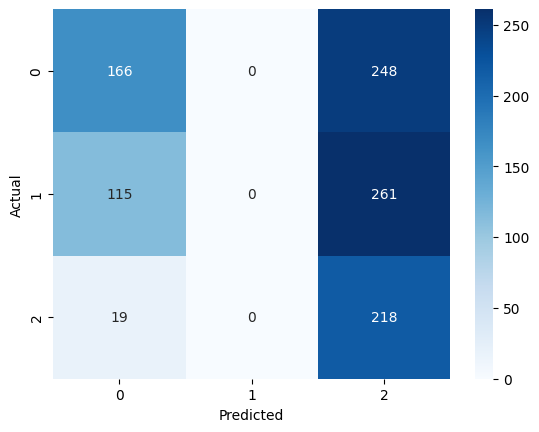

In [45]:
sn.heatmap(cm_ar_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Results of fine-tuned model are worse than the Arabic base model.


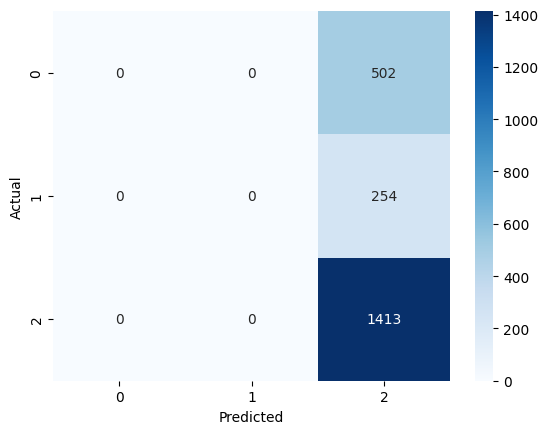

In [46]:
sn.heatmap(cm_en_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Results of fine-tuned model worse than the English base model.

## Test Base Models With More Dataset Data:

In [43]:
x_ar, Y_ar = df_ar['review'], df_ar['label']

x_train_ar_f, x_test_ar_f, y_train_ar_f, y_test_ar_f = train_test_split(list(x_ar), list(Y_ar), test_size=0.2, random_state=42, shuffle=True, stratify=df_ar['label'])

In [27]:
# will try the Arabic & English models again:

r_ar = pipeline_ar(list(dataset_test_ar['review']))

In [29]:
r_en = pipeline_en(list(dataset_test_en['review']), truncation=True, max_length=512)

In [42]:
labels_ar, labels_en = extractLabels(r_ar, r_en)

In [35]:
cm_ar = confusion_matrix(y_true=list(dataset_test_ar['label']), y_pred=labels_ar)

cm_en = confusion_matrix(y_true=list(dataset_test_en['label']), y_pred=labels_en)

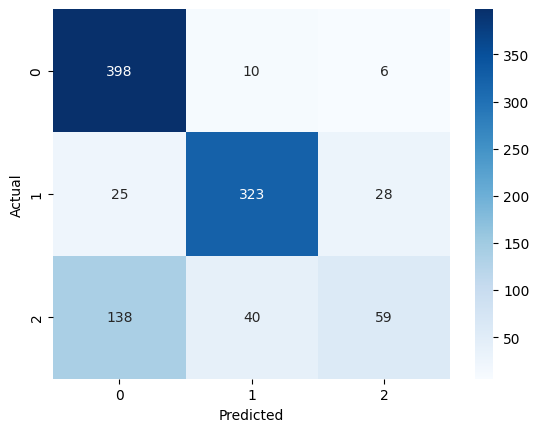

In [37]:
sn.heatmap(cm_ar, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Base Arabic model create better results than fine-tuned model.

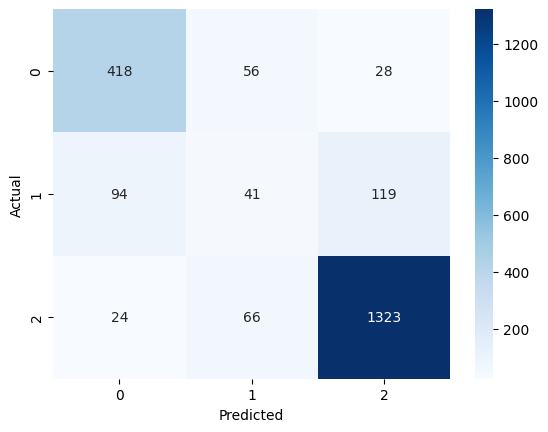

In [47]:
sn.heatmap(cm_en, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

- The model create better results for pos, neg reviews than fine-tuned model, but natuaral reviews not.
- At this project we focus more on Arabic model because almost of reviews are Arbic.

## Try New English Model:

- Sometimes, the model not fit your needs, so will choose another, lite and strong model for semantic-analysis English reviews.

In [49]:
secModelEn = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"

pipline_en_2 = pipeline('sentiment-analysis', model=secModelEn)

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Test model:

In [51]:
pred_2model = pipline_en_2(list(dataset_test_en['review']), truncation=True, max_length=512)

In [52]:
label2_ar, label2_en = extractLabels(r_ar, pred_2model)

In [53]:
cm2_en = cm_en = confusion_matrix(y_true=list(dataset_test_en['label']), y_pred=label2_en)

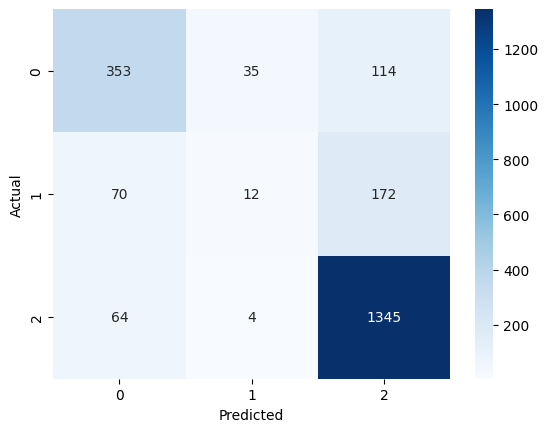

In [54]:
sn.heatmap(cm2_en, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

The model create worse results than older one.